In [ ]:
import pandas as pd
df = pd.read_csv("/content/df_file.csv")


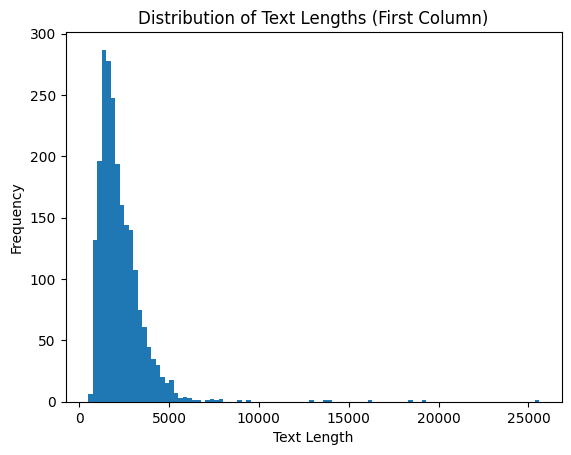

count     2225.000000
mean      2275.363596
std       1370.782663
min        507.000000
25%       1455.000000
50%       1979.000000
75%       2815.000000
max      25597.000000
Name: Text, dtype: float64


In [ ]:
import matplotlib.pyplot as plt

# Get first column
text_col = df.iloc[:, 0]

# Compute length of each entry (number of characters)
lengths = text_col.astype(str).apply(len)

# Plot
plt.figure()
plt.hist(lengths, bins=100)
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.title("Distribution of Text Lengths (First Column)")
plt.show()
print(lengths.describe())

In [ ]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

count    2225.000000
mean      210.244494
std       121.542098
min        46.000000
25%       136.000000
50%       183.000000
75%       260.000000
max      2155.000000
Name: Text, dtype: float64
Max token length: 2155


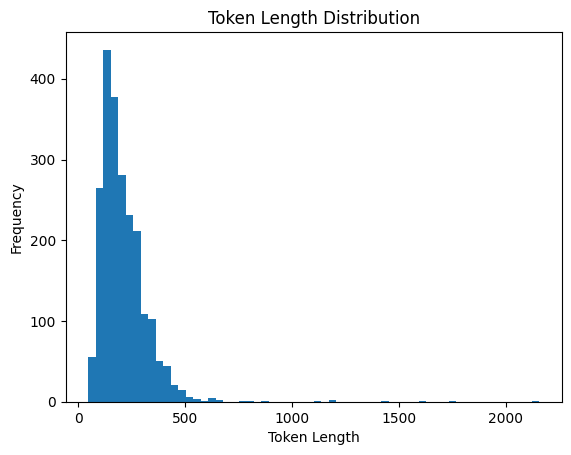

In [ ]:
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# initialize tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# preprocessing function
def preprocess(text):
    tokens = word_tokenize(str(text).lower())
    tokens = [w for w in tokens if w.isalpha()]          # remove punctuation
    tokens = [w for w in tokens if w not in stop_words]  # remove stopwords
    tokens = [lemmatizer.lemmatize(w) for w in tokens]   # lemmatize
    return " ".join(tokens)

# clean first column
df.iloc[:,0] = df.iloc[:,0].apply(preprocess)

# compute token lengths
token_lengths = df.iloc[:,0].apply(lambda x: len(x.split()))

# print statistics
print(token_lengths.describe())
print("Max token length:", token_lengths.max())

# plot distribution
plt.figure()
plt.hist(token_lengths, bins=60)
plt.xlabel("Token Length")
plt.ylabel("Frequency")
plt.title("Token Length Distribution")
plt.show()

In [ ]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode labels BEFORE split so both use same encoder
label_encoder = LabelEncoder()
df.iloc[:,1] = label_encoder.fit_transform(df.iloc[:,1])

# split dataset 80-20
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

# custom dataset
class TextDataset(Dataset):
    def __init__(self, dataframe):
        self.texts = dataframe.iloc[:,0].tolist()
        self.labels = dataframe.iloc[:,1].tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return {
            "text": self.texts[idx],
            "label": self.labels[idx]
        }

# create datasets
train_dataset = TextDataset(train_df)
val_dataset = TextDataset(val_df)

# dataloaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Number of classes:", len(label_encoder.classes_))

Train size: 1780
Validation size: 445
Number of classes: 5


In [ ]:
import torch
from transformers import AutoTokenizer, BertForSequenceClassification
from torch.optim import AdamW
import time

start = time.time()
# tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# model
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(label_encoder.classes_)
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)

model.train()

for batch in train_loader:

    optimizer.zero_grad()

    texts = batch["text"]

    labels = torch.tensor(batch["label"], dtype=torch.long).to(device)

    encodings = tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors="pt"
    )

    input_ids = encodings["input_ids"].to(device)
    attention_mask = encodings["attention_mask"].to(device)

    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        labels=labels
    )

    loss = outputs.loss
    loss.backward()
    optimizer.step()

print("Training complete!")
end = time.time()
print("Time taken:", end - start)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/tmp/ipykernel_3935/2021581975.py:29:

Training complete!
Time taken: 150.86508536338806


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
import torch

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        texts = batch["text"]
        labels = batch["label"]

        encodings = tokenizer(
            list(texts),
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        )

        input_ids = encodings["input_ids"].to(device)
        attention_mask = encodings["attention_mask"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels)

# metrics
print("Accuracy: ", accuracy_score(all_labels, all_preds))
print("Precision:", precision_score(all_labels, all_preds, average="weighted"))
print("Recall:   ", recall_score(all_labels, all_preds, average="weighted"))

Accuracy:  0.952808988764045
Precision: 0.9561991341937324
Recall:    0.952808988764045


In [ ]:
import torch
from transformers import AutoTokenizer, BertForSequenceClassification
from torch.optim import AdamW
import time

start = time.time()


tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(label_encoder.classes_)
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)

model.train()

for batch in train_loader:

    optimizer.zero_grad()

    texts = batch["text"]
    labels = torch.tensor(batch["label"], dtype=torch.long).to(device)

    # get token lengths for each text in the batch
    token_lengths = [len(tokenizer.tokenize(t)) for t in texts]

    # split indices into 3 buckets
    bucket1_idx = [i for i, l in enumerate(token_lengths) if l <= 128]
    bucket2_idx = [i for i, l in enumerate(token_lengths) if 129 <= l <= 256]
    bucket3_idx = [i for i, l in enumerate(token_lengths) if l > 256]

    for idx_group, max_len in [(bucket1_idx, 128), (bucket2_idx, 256), (bucket3_idx, 512)]:
        if not idx_group:
            continue

        sub_texts  = [texts[i] for i in idx_group]
        sub_labels = labels[idx_group]

        encodings = tokenizer(
            sub_texts,
            padding=True,
            truncation=True,
            max_length=max_len,
            return_tensors="pt"
        )

        input_ids      = encodings["input_ids"].to(device)
        attention_mask = encodings["attention_mask"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=sub_labels
        )

        loss = outputs.loss
        loss.backward()

    optimizer.step()

print("Training complete!")
end = time.time()
print("time taken", end - start)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/tmp/ipykernel_3935/1630251291.py:28:

Training complete!
time taken 110.81573438644409


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
import torch

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        texts = batch["text"]
        labels = batch["label"]

        encodings = tokenizer(
            list(texts),
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        )

        input_ids = encodings["input_ids"].to(device)
        attention_mask = encodings["attention_mask"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels)

# metrics
print("Accuracy: ", accuracy_score(all_labels, all_preds))
print("Precision:", precision_score(all_labels, all_preds, average="weighted"))
print("Recall:   ", recall_score(all_labels, all_preds, average="weighted"))

Accuracy:  0.9550561797752809
Precision: 0.9563673676798149
Recall:    0.9550561797752809


In [13]:
import torch
from transformers import AutoTokenizer, BertForSequenceClassification
from torch.optim import AdamW
import time
start = time.time()

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(label_encoder.classes_)
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)

# ── Step 1: tokenize every training sample individually ──────────────────────
all_input_ids = []
all_attention_masks = []
all_labels = []

for batch in train_loader:
    texts  = batch["text"]
    labels = batch["label"]

    for text, label in zip(texts, labels):
        enc = tokenizer(
            text,
            truncation=True,
            max_length=510,          # leave room for [CLS] and [SEP]
            return_tensors="pt"
        )
        # strip the batch dim → 1-D tensors
        all_input_ids.append(enc["input_ids"].squeeze(0))
        all_attention_masks.append(enc["attention_mask"].squeeze(0))
        all_labels.append(label)

# ── Step 2: pack samples into 512-token sequences ────────────────────────────
CLS_ID = tokenizer.cls_token_id   # 101
SEP_ID = tokenizer.sep_token_id   # 102
MAX_LEN = 512

packed_input_ids      = []
packed_attention_masks = []
packed_labels         = []
packed_token_type_ids = []

current_ids      = []
current_mask     = []
current_type_ids = []
current_labels   = []
segment_id       = 0               # alternates 0/1 so BERT sees distinct segments

for ids, mask, label in zip(all_input_ids, all_attention_masks, all_labels):

    ids  = ids.tolist()
    mask = mask.tolist()

    # total tokens this sample needs (already has [CLS] and [SEP])
    needed = len(ids)

    # if it doesn't fit in the current pack → flush and start a new one
    if len(current_ids) + needed > MAX_LEN:

        # pad the current pack to MAX_LEN
        pad_len = MAX_LEN - len(current_ids)
        current_ids      += [tokenizer.pad_token_id] * pad_len
        current_mask     += [0] * pad_len
        current_type_ids += [0] * pad_len

        packed_input_ids.append(torch.tensor(current_ids))
        packed_attention_masks.append(torch.tensor(current_mask))
        packed_token_type_ids.append(torch.tensor(current_type_ids))
        packed_labels.append(current_labels)   # list of labels in this pack

        # reset
        current_ids      = []
        current_mask     = []
        current_type_ids = []
        current_labels   = []
        segment_id       = 0

    # append this sample to the current pack
    # alternate token_type_ids (0/1) so BERT distinguishes segments
    current_ids      += ids
    current_mask     += mask
    current_type_ids += [segment_id % 2] * len(ids)
    current_labels.append(int(label))
    segment_id += 1

# flush the last pack
if current_ids:
    pad_len = MAX_LEN - len(current_ids)
    current_ids      += [tokenizer.pad_token_id] * pad_len
    current_mask     += [0] * pad_len
    current_type_ids += [0] * pad_len

    packed_input_ids.append(torch.tensor(current_ids))
    packed_attention_masks.append(torch.tensor(current_mask))
    packed_token_type_ids.append(torch.tensor(current_type_ids))
    packed_labels.append(current_labels)

print(f"Original batches : {len(all_input_ids)} samples")
print(f"Packed sequences : {len(packed_input_ids)} sequences")
print(f"Compression ratio: {len(all_input_ids)/len(packed_input_ids):.2f}x")

# ── Step 3: train on packed sequences ────────────────────────────────────────
model.train()

PACK_BATCH_SIZE = 16

for batch_start in range(0, len(packed_input_ids), PACK_BATCH_SIZE):

    optimizer.zero_grad()

    batch_ids       = packed_input_ids[batch_start : batch_start + PACK_BATCH_SIZE]
    batch_masks     = packed_attention_masks[batch_start : batch_start + PACK_BATCH_SIZE]
    batch_type_ids  = packed_token_type_ids[batch_start : batch_start + PACK_BATCH_SIZE]
    batch_lbl_lists = packed_labels[batch_start : batch_start + PACK_BATCH_SIZE]

    input_ids        = torch.stack(batch_ids).to(device)
    attention_mask   = torch.stack(batch_masks).to(device)
    token_type_ids   = torch.stack(batch_type_ids).to(device)

    # forward pass (no labels — we extract CLS per segment manually)
    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        token_type_ids=token_type_ids
    )

    logits = outputs.logits   # (batch_size, num_labels)

    # each packed sequence contributes one logit row → use it for the
    # FIRST label in that pack (standard approach for packed classification)
    flat_labels = torch.tensor(
        [lbls[0] for lbls in batch_lbl_lists],
        dtype=torch.long
    ).to(device)

    loss_fn = torch.nn.CrossEntropyLoss()
    loss = loss_fn(logits, flat_labels)

    loss.backward()
    optimizer.step()

print("Training complete!")
end = time.time()
print("time taken", end - start)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Original batches : 1780 samples
Packed sequences : 1062 sequences
Compression ratio: 1.68x
Training complete!
time taken 117.67123937606812
